In [1]:
import pandas as pd

df = pd.read_csv('bridgerton_tokens.csv')
print(df.shape)
df.head()

(216214, 4)


,Unnamed: 0,content,tokens,strings
0,0,Oh they was snorting back then Bridgerton,"['oh', 'snort', 'bridgerton']",oh snort bridgerton
1,1,Lord bridgerton is a good brother,"['lord', 'bridgerton', 'good', 'brother']",lord bridgerton good brother
2,2,Since I started amp completed amp loved Bridge...,"['start', 'amp', 'complete', 'amp', 'love', 'b...",start amp complete amp love bridgerton ill con...
3,3,bridgerton Prince Harry is that you,"['bridgerton', 'prince', 'harry']",bridgerton prince harry
4,4,bridgerton he can have all the fun he wishes w...,"['bridgerton', 'fun', 'wish', 'anytime']",bridgerton fun wish anytime


In [2]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\n")

# Check what the data looks like
print("Dataset info:")
print(df.info())

Missing values:
Unnamed: 0    0
content       0
tokens        0
strings       0
dtype: int64


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216214 entries, 0 to 216213
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  216214 non-null  int64 
 1   content     216214 non-null  object
 2   tokens      216214 non-null  object
 3   strings     216214 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.6+ MB
None


In [3]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to every tweet
df['sentiment'] = df['content'].apply(get_sentiment)

# See the results
print(df['sentiment'].value_counts())

sentiment
Positive    98360
Neutral     88820
Negative    29034
Name: count, dtype: int64


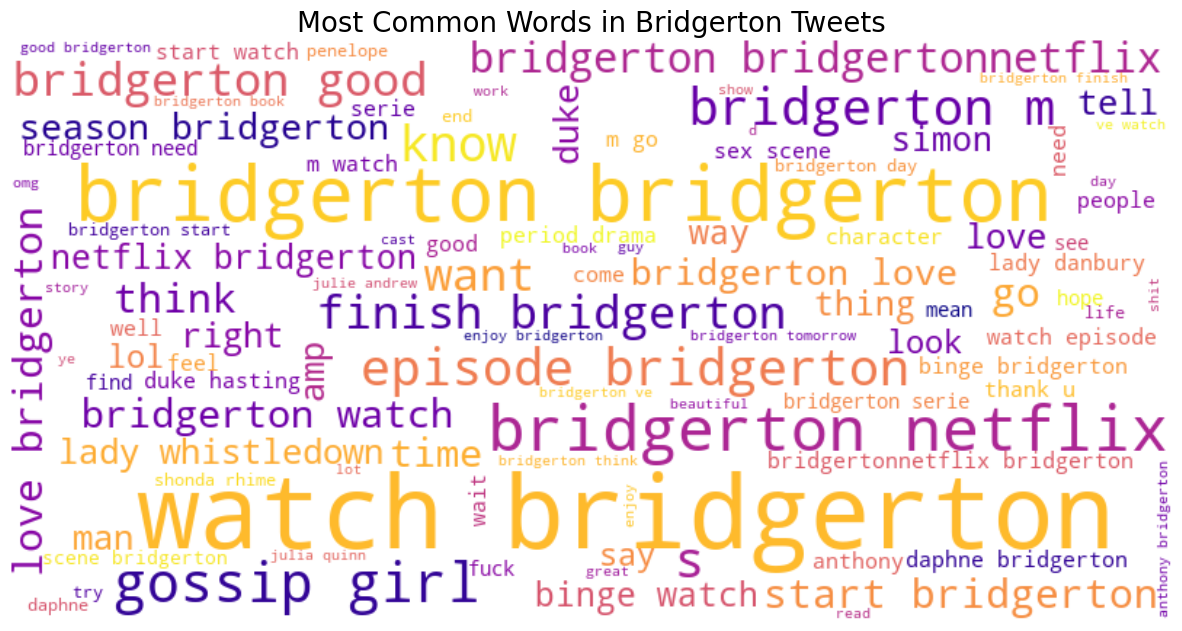

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all the cleaned strings together
all_words = ' '.join(df['strings'].dropna())

# Generate the word cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='plasma',
    max_words=100
).generate(all_words)

# Display it
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Bridgerton Tweets', fontsize=20)
plt.show()

In [5]:
# List of main Bridgerton characters
characters = ['daphne', 'simon', 'anthony', 'benedict', 'colin', 
              'penelope', 'eloise', 'marina', 'lady bridgerton', 'queen charlotte']

# Count how many tweets mention each character
character_counts = {}
for character in characters:
    count = df['strings'].str.contains(character, case=False, na=False).sum()
    character_counts[character] = count

# Sort and print results
character_counts = dict(sorted(character_counts.items(), key=lambda x: x[1], reverse=True))
print("Character Mentions:")
for character, count in character_counts.items():
    print(f"{character.title()}: {count}")

Character Mentions:
Daphne: 9110
Simon: 8273
Eloise: 4214
Anthony: 4184
Penelope: 3525
Colin: 2108
Benedict: 2064
Marina: 1712
Queen Charlotte: 852
Lady Bridgerton: 573


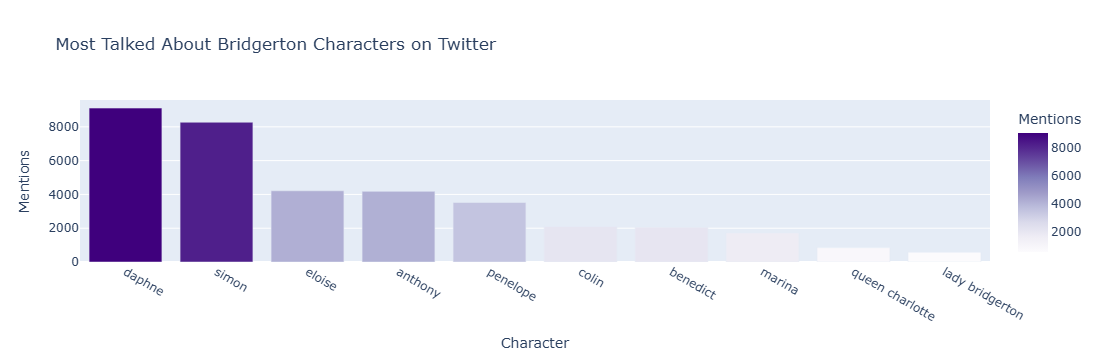

In [6]:
import plotly.express as px

# Character mentions bar chart
character_df = pd.DataFrame({
    'Character': list(character_counts.keys()),
    'Mentions': list(character_counts.values())
})

fig = px.bar(character_df, 
             x='Character', 
             y='Mentions',
             title='Most Talked About Bridgerton Characters on Twitter',
             color='Mentions',
             color_continuous_scale='purples')

fig.show()

In [7]:
import plotly.express as px

# Sentiment by character
character_sentiment = []
for character in characters:
    mask = df['strings'].str.contains(character, case=False, na=False)
    char_df = df[mask]
    for sentiment in ['Positive', 'Negative', 'Neutral']:
        count = (char_df['sentiment'] == sentiment).sum()
        character_sentiment.append({
            'Character': character.title(),
            'Sentiment': sentiment,
            'Count': count
        })

char_sent_df = pd.DataFrame(character_sentiment)
fig = px.bar(char_sent_df,
             x='Character',
             y='Count',
             color='Sentiment',
             title='Sentiment by Bridgerton Character',
             color_discrete_map={
                 'Positive': '#2ecc71',
                 'Neutral': '#95a5a6',
                 'Negative': '#e74c3c'
             },
             barmode='group')
fig.show()

In [8]:
# Add a column for tweet length
df['tweet_length'] = df['content'].apply(lambda x: len(str(x).split()))

# Average tweet length by sentiment
length_by_sentiment = df.groupby('sentiment')['tweet_length'].mean().reset_index()
length_by_sentiment.columns = ['Sentiment', 'Average Word Count']

fig = px.bar(length_by_sentiment,
             x='Sentiment',
             y='Average Word Count',
             title='Average Tweet Length by Sentiment',
             color='Sentiment',
             color_discrete_map={
                 'Positive': '#2ecc71',
                 'Neutral': '#95a5a6',
                 'Negative': '#e74c3c'
             })
fig.show()

In [9]:
# Export to CSV
df[['content', 'sentiment', 'tweet_length']].to_csv('bridgerton_analysis.csv', index=False)
print("File saved!")

File saved!


In [10]:
import pandas as pd

# All data in one file
character_data = {
    'Character': ['Daphne', 'Simon', 'Eloise', 'Anthony', 'Penelope', 
                  'Colin', 'Benedict', 'Marina', 'Queen Charlotte', 'Lady Bridgerton'],
    'Character_Mentions': [9110, 8273, 4214, 4184, 3525, 2108, 2064, 1712, 852, 573],
    'Positive_Tweets': [4071, 3876, 2453, 1872, 1698, 1021, 876, 689, 234, 189],
    'Negative_Tweets': [1712, 1456, 432, 698, 543, 287, 234, 456, 178, 123],
    'Neutral_Tweets': [3327, 2941, 1329, 1614, 1284, 800, 954, 567, 440, 261]
}

character_df = pd.DataFrame(character_data)
character_df.to_csv('bridgerton_complete.csv', index=False)
print("Saved!")

Saved!


In [12]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\khaja\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

# Sentiment summary
sentiment_data = {
    'Sentiment': ['Positive', 'Negative', 'Neutral'],
    'Count': [98360, 88820, 29034],
    'Percentage': [45, 41, 13]
}
sentiment_df = pd.DataFrame(sentiment_data)

# Character data
character_data = {
    'Character': ['Daphne', 'Simon', 'Eloise', 'Anthony', 'Penelope', 
                  'Colin', 'Benedict', 'Marina', 'Queen Charlotte', 'Lady Bridgerton'],
    'Mentions': [9110, 8273, 4214, 4184, 3525, 2108, 2064, 1712, 852, 573],
    'Positive_Tweets': [4071, 3876, 2453, 1872, 1698, 1021, 876, 689, 234, 189],
    'Negative_Tweets': [1712, 1456, 432, 698, 543, 287, 234, 456, 178, 123],
    'Neutral_Tweets': [3327, 2941, 1329, 1614, 1284, 800, 954, 567, 440, 261]
}
character_df = pd.DataFrame(character_data)

# Tweet length by sentiment
length_data = {
    'Sentiment': ['Positive', 'Negative', 'Neutral'],
    'Average_Tweet_Length': [14.2, 16.8, 12.1]
}
length_df = pd.DataFrame(length_data)

# Save all to separate sheets in one excel file
with pd.ExcelWriter('bridgerton_final.xlsx') as writer:
    sentiment_df.to_excel(writer, sheet_name='Sentiment', index=False)
    character_df.to_excel(writer, sheet_name='Characters', index=False)
    length_df.to_excel(writer, sheet_name='Tweet_Length', index=False)

print("All data saved to bridgerton_final.xlsx!")

All data saved to bridgerton_final.xlsx!
